In [1]:
# libraries-
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# loading dataset-
df = pd.read_csv('online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# basic inspections-
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [4]:
df.shape

(1067371, 8)

In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [8]:
# duplicated-
df.duplicated().sum()

np.int64(34335)

In [9]:
df[df.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [10]:
df[df.duplicated(keep=False)].sort_values(['Invoice','StockCode'])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom


In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1033036, 8)

In [14]:
df[df.duplicated(keep=False)].sort_values(['Invoice','StockCode'])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [15]:
df= df.dropna(subset=['Customer ID'])

In [16]:
df.shape

(797885, 8)

In [17]:
df[df['Quantity'] <= 0].shape

(18390, 8)

In [18]:
# Check negative -
df[df['Quantity'] <= 0]['Quantity'].value_counts().head(20)

Quantity
-1      8008
-2      2730
-3      1279
-12     1072
-4       991
-6       956
-24      455
-5       373
-8       305
-10      273
-7       154
-48      152
-36      109
-9        98
-16       98
-11       77
-20       76
-18       62
-100      61
-25       60
Name: count, dtype: int64

In [19]:
# check negative cancellation-
df[df['Invoice'].astype(str).str.startswith('C')].shape

(18390, 8)

In [20]:
df[df['Invoice'].astype(str).str.startswith('C')].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [21]:
# remove cancellation/returns
df = df[df['Quantity'] > 0]

In [22]:
df[df['Price'] <= 0].shape

(70, 8)

In [23]:
# remove invalid price
df = df[df['Price'] > 0]

In [24]:
print(df.shape)

(779425, 8)


In [25]:
print(df.shape)

print((df['Quantity'] <= 0).sum())

print((df['Price'] <= 0).sum())

print(df['Customer ID'].isna().sum())

print(df.duplicated().sum())

(779425, 8)
0
0
0
0


In [26]:
# create revenue column-
df['Revenue'] = df['Quantity'] * df['Price']

In [27]:
df[['Quantity','Price','Revenue']].describe()

,Quantity,Price,Revenue
count,779425.000000,779425.000000,779425.000000
mean,13.489370,3.218488,22.291823
std,145.855814,29.676140,227.427075
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.480000
75%,12.000000,3.750000,19.800000
max,80995.000000,10953.500000,168469.600000


In [28]:
df.shape

(779425, 9)

In [29]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [30]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 59.5 MB


# Calculate Core KPIs

In [32]:
total_revenue = df['Revenue'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = total_revenue / total_orders

print(f'Revenue : {total_revenue:,.2f}')
print(f'Orders : {total_orders}')
print(f'Customers : {total_customers}')
print(f'AOV : {avg_order_value:,.2f}')

Revenue : 17,374,804.27
Orders : 36969
Customers : 5878
AOV : 469.98


# Monthly Revenue

In [33]:
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].astype(str)

monthly_sales.head()

,InvoiceDate,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


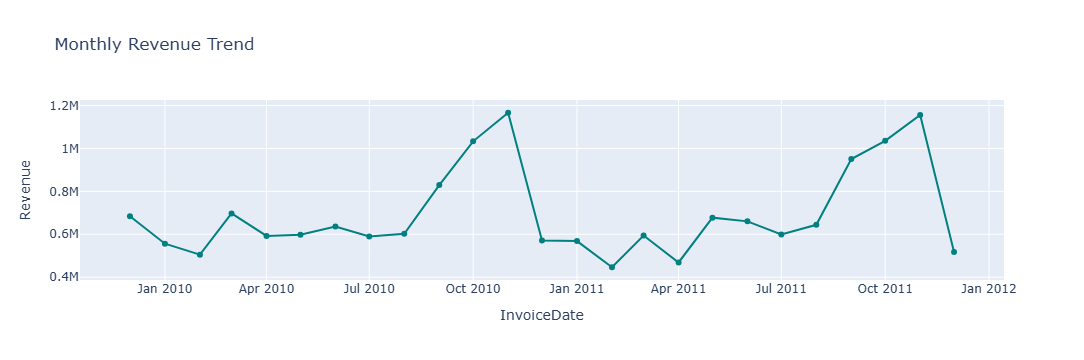

Revenue consistently peaks during September–November, indicating strong seasonal demand leading into the holiday shopping period.


In [34]:
fig = px.line(monthly_sales,x='InvoiceDate',y='Revenue',
             title= 'Monthly Revenue Trend',
             markers=True)
fig.update_traces(line_shape='linear',line=dict(width=2, color='teal'))
fig.show()

print('Revenue consistently peaks during September–November, indicating strong seasonal demand leading into the holiday shopping period.')

## Revenue dropped sharply in December 2011; however, the dataset contains transactions only through December 9, 2011.
## Therefore, December 2011 represents a partial month and is not directly comparable with previous months.

In [35]:
product_df = df[
    ~df["Description"].isin(["Manual", "POSTAGE"])
]

# Top 10 Products

In [36]:
top_products = product_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               134307.44
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
CHILLI LIGHTS                          69084.30
JUMBO BAG STRAWBERRY                   64127.77
Name: Revenue, dtype: float64

# Top 10 Countries 

In [37]:
top_countries = (
    df.groupby("Country")
      .agg(
          Revenue=("Revenue","sum"),
          Orders=("Invoice","nunique"),
          Customers=("Customer ID","nunique")
      )
      .sort_values("Revenue", ascending=False)
)

top_countries.head(10)

,Revenue,Orders,Customers
Country,,,
United Kingdom,1.438923e+07,33541,5350
EIRE,6.165705e+05,567,5
Netherlands,5.540381e+05,228,22
Germany,4.250197e+05,789,107
France,3.487690e+05,614,95
Australia,1.692835e+05,95,15
Spain,1.083325e+05,154,41
Switzerland,1.000619e+05,90,22
Sweden,9.151582e+04,104,19


## UK contributes roughly 80%+ of total revenue.

# Top 10 Countries excludeing UK

In [38]:
countries_ex_uk = (
    top_countries
    .drop("United Kingdom")
)

In [39]:
countries_ex_uk.head(10)

,Revenue,Orders,Customers
Country,,,
EIRE,616570.540,567,5
Netherlands,554038.090,228,22
Germany,425019.711,789,107
France,348768.960,614,95
Australia,169283.460,95,15
Spain,108332.490,154,41
Switzerland,100061.940,90,22
Sweden,91515.820,104,19
Denmark,68580.690,43,12


# Customer Analysis

In [40]:
top_customers = (
    df.groupby("Customer ID")
      .agg(
          Revenue=("Revenue","sum"),
          Orders=("Invoice","nunique")
      )
      .sort_values("Revenue", ascending=False)
)

top_customers.head(10)

,Revenue,Orders
Customer ID,,
18102.0,580987.04,145
14646.0,528602.52,151
14156.0,313437.62,156
14911.0,291420.81,398
17450.0,244784.25,51
13694.0,195640.69,143
17511.0,172132.87,60
16446.0,168472.50,2
16684.0,147142.77,55


In [41]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

customer_revenue.head(10)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

In [42]:
top10_share = (
    customer_revenue.head(10).sum()
    / customer_revenue.sum()
) * 100

print(f"Top 10 Customer Revenue Share: {top10_share:.2f}%")

Top 10 Customer Revenue Share: 16.04%


In [43]:
customer_revenue.describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Revenue, dtype: float64

In [44]:
df.to_csv('Clean_retail.csv',index=False)

# RFM Segmentation

In [45]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='str')

In [49]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate':lambda x:(snapshot_date - x.max()).days,
    'Invoice' : 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


# Create Scores

In [64]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [65]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

In [66]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# Customer Segmentation

In [67]:
def segment_customer(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Recent Customers'

    elif row['F_Score'] >= 4:
        return 'Frequent Customers'

    elif row['R_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [68]:
rfm['Segment'].value_counts()

Segment
At Risk               1994
Loyal Customers       1013
Recent Customers       882
Frequent Customers     869
Others                 651
Champions              469
Name: count, dtype: int64

In [69]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions             8145262.814
Loyal Customers       3879067.331
Frequent Customers    2782622.647
At Risk               1153116.742
Recent Customers       871585.661
Others                 543149.073
Name: Monetary, dtype: float64

In [70]:
469 / 5878

0.07978904389248044

## A small group of high-value customers contributes a disproportionate share of revenue, 
## highlighting the importance of retention strategies focused on Champion customers.

In [72]:
rfm.to_csv("rfm_segmentation.csv")

In [73]:
rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

,Recency,Frequency,Monetary
Segment,,,
At Risk,442.385657,1.657974,578.293251
Champions,7.850746,28.739872,17367.298111
Frequent Customers,202.940161,8.143843,3202.097407
Loyal Customers,26.161895,9.601185,3829.286605
Others,109.660522,2.093702,834.330373
Recent Customers,26.512472,2.287982,988.192359
